In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import matplotlib as mpl
import warnings; warnings.simplefilter('ignore')
import os
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_stellarhalo
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_simload
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [85]:
# test = jsm_visualize.Arborist(file="../../../StellarHalo/data/local_trees/low_res/tree_0_evo.npz", merger_crit=-2, fesc=0.2, scatter=True, verbose=False)
test = jsm_visualize.Arborist(file="../../data/local_trees/evolved_trees/tree_13.8.npz", merger_crit=-2, fesc=0.2, scatter=True, verbose=False)

test.plant_roots()
test.water_roots()
test.dendrochronology(mass_threshold=1e10,kmax=2,verbose=True)

surviving 0.0 [6.24733967e+12 1.20399322e+11] 63095734448017.88
--------------------------------
rvir 0.0 [3.75588687e+12 0.00000000e+00] 63095734448017.88
--------------------------------
artificial 0.0 [3.41997296e+12 0.00000000e+00] 63095734448017.88
--------------------------------
surviving 0.0043088168410465736 [6.28258589e+12 1.20399322e+11] 63067714116763.56
--------------------------------
rvir 0.0043088168410465736 [3.92652949e+12 0.00000000e+00] 63067714116763.56
--------------------------------
artificial 0.0043088168410465736 [3.57730342e+12 0.00000000e+00] 63067714116763.56
--------------------------------
surviving 0.008644681525374957 [6.31947640e+12 1.20399322e+11] 63034689697536.766
--------------------------------
rvir 0.008644681525374957 [3.90054273e+12 0.00000000e+00] 63034689697536.766
--------------------------------
artificial 0.008644681525374957 [3.5388629e+12 0.0000000e+00] 63034689697536.766
--------------------------------
surviving 0.013007871470214273 [6

In [92]:
test = jsm_visualize.Arborist(file="../../../StellarHalo/data/local_trees/low_res/tree_0_evo.npz", merger_crit=-2, fesc=0.2, scatter=True, verbose=False)

test.plant_roots()
test.water_roots()
test.dendrochronology(mass_threshold=1e10,kmax=2,verbose=True)

surviving 0.0 [1.04679216e+11 0.00000000e+00] 1000000000000.0
--------------------------------
rvir 0.0 [6.7818512e+10 0.0000000e+00] 1000000000000.0
--------------------------------
artificial 0.0 [6.7818512e+10 0.0000000e+00] 1000000000000.0
--------------------------------
surviving 0.0043088168410465736 [1.05767612e+11 0.00000000e+00] 1000000000000.0
--------------------------------
rvir 0.0043088168410465736 [6.89069083e+10 0.00000000e+00] 1000000000000.0
--------------------------------
artificial 0.0043088168410465736 [6.89069083e+10 0.00000000e+00] 1000000000000.0
--------------------------------
surviving 0.008644681525374957 [1.06718856e+11 0.00000000e+00] 997984033324.5151
--------------------------------
rvir 0.008644681525374957 [6.98581522e+10 0.00000000e+00] 997984033324.5151
--------------------------------
artificial 0.008644681525374957 [6.98581522e+10 0.00000000e+00] 997984033324.5151
--------------------------------
surviving 0.013007871470214273 [1.07499085e+11 0.0

In [93]:
test.forest[300]

In [98]:
test.forest[310].show()

Host Halo
└── subID:17



In [99]:
test.forest[310].get_node("0")
test.forest[310].get_node("17")

Node(tag=subID:17, identifier=17, data={'mass': 358323910.5601151, 'rmag': nan})

In [105]:
for i in range(300, 312):
    print(i, test.forest[i].get_node("0").data["mass"])

300 729037197.1373726
301 653147005.7246287
302 585119942.2223065
303 585119942.2223065
304 524145555.67836607
305 469496350.270902
306 469496350.270902
307 420519499.84055907
308 376629185.69876385
309 376629185.69876385
310 nan
311 nan


In [111]:
for i in range(300, 311):
    print(i, test.forest[i].get_node("17").data["mass"])

300 693813642.7496526
301 693813642.7496526
302 621557698.6628958
303 556792135.1251519
304 556792135.1251519
305 498744448.7305207
306 446721284.7016229
307 446721284.7016229
308 400100519.3460652
309 358323910.5601151
310 358323910.5601151


In [112]:
test.forest[308].show()

Host Halo
├── subID:15
└── subID:17



In [115]:
for i in range(300, 310):
    print(i, test.forest[i].get_node("15").data["mass"])

300 729349787.9396753
301 653425672.2774289
302 585368365.4533799
303 585368365.4533799
304 524367017.11455655
305 469693775.7016686
306 469693775.7016686
307 420695496.19582677
308 376786077.96816707
309 376786077.96816707


In [100]:
test.forest[310].get_node("17").data["mass"]

358323910.5601151

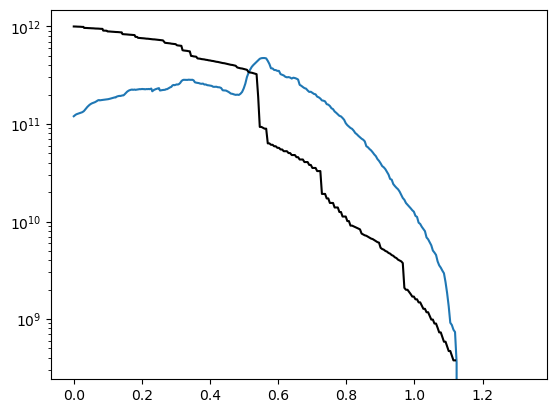

In [125]:
plt.plot(np.log10(1+cfg.zsample), np.nansum(test.mass[1:, :], axis=0))
plt.plot(np.log10(1+cfg.zsample), test.mass[0, :], color="k")
plt.yscale("log")


In [300]:
test = jsm_visualize.Arborist(file="../../data/local_trees/evolved_trees/tree_13.8.npz", merger_crit=-2, fesc=0.2, scatter=True, verbose=False)

In [301]:
Ntime = test.order.shape[1]
subhalo_mask_all = np.zeros((test.Nhalo, Ntime), dtype=bool)

for t in range(Ntime):
    k_t   = test.order[:, t]      # (Nsub,)
    pid_t = test.ParentID[:, t]   # (Nsub,)

    exists_t = (k_t != -99)       # accreted-by-time-t mask

    pid_safe = np.where(pid_t == -99, 0, pid_t)  # sanitize sentinel before using as index

    belongs = np.zeros(test.Nhalo, dtype=bool)
    belongs[0] = True  # host trivially "belongs" to itself, sets the recursion base case

    for order in range(1, k_t.max() + 1):
        mask_k = (k_t == order)
        belongs |= mask_k & belongs[pid_safe]  # inherit parent's status, gathered via sanitized ParentID

    subhalo_mask_all[:, t] = belongs & exists_t & (np.arange(test.Nhalo) != 0)  # drop host row itself

masked_mass = np.where(subhalo_mask_all, test.mass, 0.0)  # (Nhalo, Ntime), zero out non-subhalo rows
total_subhalo_mass = masked_mass.sum(axis=0)

total_subhalos = np.sum(subhalo_mask_all, axis=0)

inside_rvir_mask = test.rmags_stitched < test.VirialRadius[0][None, :]  # broadcast (t,) -> (1, t) against (Nhalo, t)
subhalo_and_inside_rvir = subhalo_mask_all & inside_rvir_mask

total_subhalos_inside_Rvir = np.sum(subhalo_and_inside_rvir, axis=0)

total_subhalo_mass_inside_Rvir = np.where(subhalo_and_inside_rvir, test.mass, 0.0).sum(axis=0)
total_fsub_inside_Rvir = total_subhalo_mass_inside_Rvir/test.mass[0]

mass_threshold = 0.0001*(10**(13.8))  # example threshold, adjust as needed

# --- Mask 1: based on mass at accretion (test.acc_mass, shape (Nsub,)) ---
acc_mass_mask = (test.acc_mass > mass_threshold)[:, None]  # (Nsub,) -> (Nsub, 1), broadcasts across time

subhalo_acc_mass_cut = subhalo_and_inside_rvir & acc_mass_mask  # (Nhalo, Ntime)

total_subhalos_acc_cut   = subhalo_acc_mass_cut.sum(axis=0)
total_mass_acc_cut       = np.where(subhalo_acc_mass_cut, test.mass, 0.0).sum(axis=0)
total_fsub_acc_cut       = total_mass_acc_cut / test.mass[0]

# --- Mask 2: based on final (present-day) mass, test.mass[:, 0] ---
final_mass_mask = (test.mass[:, 0] > mass_threshold)[:, None]  # (Nsub,) -> (Nsub, 1), broadcasts across time

subhalo_final_mass_cut = subhalo_and_inside_rvir & final_mass_mask  # (Nhalo, Ntime)

total_subhalos_final_cut = subhalo_final_mass_cut.sum(axis=0)
total_mass_final_cut     = np.where(subhalo_final_mass_cut, test.mass, 0.0).sum(axis=0)
total_fsub_final_cut     = total_mass_final_cut / test.mass[0]

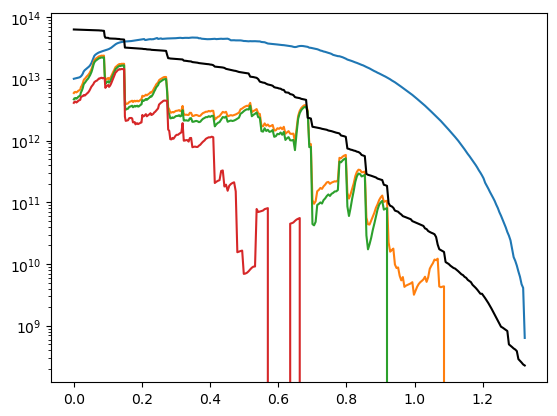

In [302]:
plt.plot(np.log10(1+cfg.zsample), total_subhalo_mass)
plt.plot(np.log10(1+cfg.zsample), total_subhalo_mass_inside_Rvir)

plt.plot(np.log10(1+cfg.zsample), total_mass_acc_cut)
plt.plot(np.log10(1+cfg.zsample), total_mass_final_cut)

plt.plot(np.log10(1+cfg.zsample), test.mass[0, :], color="k")
plt.yscale("log")

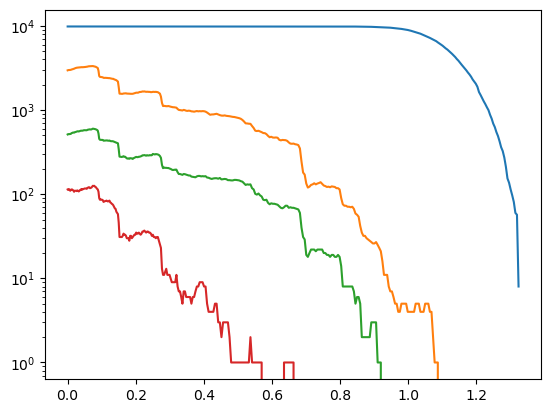

In [303]:
plt.plot(np.log10(1+cfg.zsample), total_subhalos)
plt.plot(np.log10(1+cfg.zsample), total_subhalos_inside_Rvir)

plt.plot(np.log10(1+cfg.zsample), total_subhalos_acc_cut)
plt.plot(np.log10(1+cfg.zsample), total_subhalos_final_cut)

plt.yscale("log")

In [304]:
total_subhalos[0]

9867

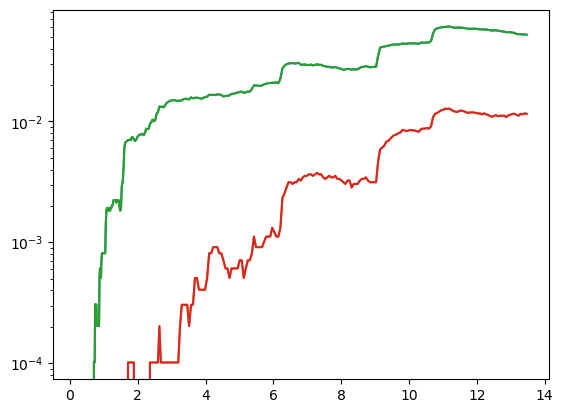

In [305]:
# plt.plot(cfg.tsample, total_subhalos)
# plt.plot(cfg.tsample, total_subhalos_inside_Rvir)

plt.plot(cfg.tsample, total_subhalos_acc_cut/total_subhalos[0])
plt.plot(cfg.tsample, total_subhalos_final_cut/total_subhalos[0])

plt.plot(cfg.tsample, total_subhalos_acc_cut/total_subhalos)
plt.plot(cfg.tsample, total_subhalos_final_cut/total_subhalos)

plt.yscale("log")

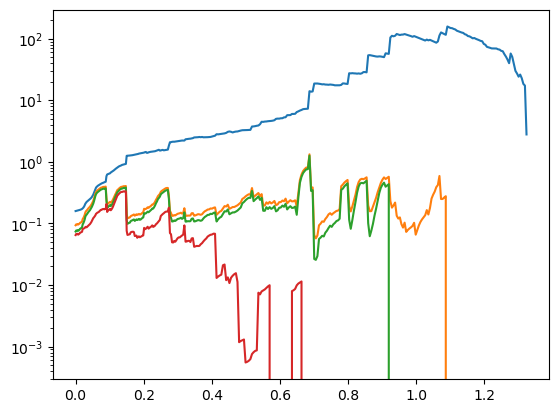

In [306]:
plt.plot(np.log10(1+cfg.zsample), total_subhalo_mass/test.mass[0])
plt.plot(np.log10(1+cfg.zsample), total_fsub_inside_Rvir)

plt.plot(np.log10(1+cfg.zsample), total_fsub_acc_cut)
plt.plot(np.log10(1+cfg.zsample), total_fsub_final_cut)

plt.yscale("log")

In [207]:
total_subhalo_mass - np.nansum(test.mass[1:, :], axis=0)

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [154]:
# for arr in test.Nsub_total.T:
#     plt.plot(np.log10(1+cfg.zsample), arr)

# for arr in test.fsub_surviving.T:
#     plt.step(np.log10(1+cfg.zsample), arr, where="mid")

for arr in test.fsub_rvir.T:
    plt.step(np.log10(1+cfg.zsample), arr, where="mid")

for arr in test.fsub_artificial.T:
    plt.step(np.log10(1+cfg.zsample), arr, where="mid")

plt.ylim(0,1) 

AttributeError: 'Arborist' object has no attribute 'fsub_rvir'

In [134]:
test.Nhalo

28